In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt
from opacus import PrivacyEngine

# Experiment parameters

In [2]:
# Set random seed for reproducibility
torch.manual_seed(0)

# Parameters
d = 10  # Dimensionality
n = 1000  # Number of data points
epochs = 10
learning_rate = 1e-1
batch_size = 32

# Data generation

In [22]:
# Generate synthetic data
mean = torch.zeros(d)  # Zero mean
cov = torch.eye(d)  # Standard Gaussian
data = torch.distributions.MultivariateNormal(mean, cov).sample((n,))
target = mean.repeat(n, 1)  # Our target is the true mean repeated

data = data + torch.normal(0, 0.5, size=(n, d))

# Create DataLoader
dataset = TensorDataset(data, target)
data_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

# Model

In [30]:
# Define a simple linear model
class LinearModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc = nn.Linear(input_dim, input_dim, bias=False)

        # Initialize weights to 1
        torch.nn.init.constant_(self.fc.weight, 1.0)

    def forward(self, x):
        return self.fc(x)

In [31]:
def train_dp_model(data_loader, epochs, learning_rate, max_grad_norm, epsilon):
    print(f'Running with maximum gradient norm: {max_grad_norm}')

    model = LinearModel(d)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Initialize Privacy Engine
    privacy_engine = PrivacyEngine()
    model, optimizer, data_loader = privacy_engine.make_private_with_epsilon(
        module=model,
        optimizer=optimizer,
        data_loader=data_loader,
        target_epsilon=epsilon,
        target_delta=1e-5,
        max_grad_norm=max_grad_norm,
        epochs=epochs,
    )

    criterion = nn.MSELoss()
    losses = []

    for epoch in range(epochs):
        print(f' - Iterate epoch: {epoch}')
        epoch_loss = 0
        for batch_data, batch_target in data_loader:
            optimizer.zero_grad()
            output = model(batch_data)
            loss = criterion(output, batch_target)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(data_loader)
        losses.append(avg_loss)

    return losses[-1]  # Return the final loss

In [33]:
def plot_results(max_grad_norms, results, epsilon):
    plt.figure(figsize=(10, 6))
    plt.plot(max_grad_norms, results, label=f"Epsilon = {epsilon}", marker='o')
    plt.xscale('log')
    plt.xlabel('Maximum Gradient Norm')
    plt.ylabel('MSE Loss')
    plt.title('Effect of Maximum Gradient Norm on Toy model')
    plt.legend()
    #plt.ylim([0, 4])
    plt.grid(True)
    plt.show()

Running for epsilon: 0.25
Running with maximum gradient norm: 0.0001


/home/arehn/git/opacus-decouple/opacus/privacy_engine.py:95: UserWarning: Secure RNG turned off. This is perfectly fine for experimentation as it allows for much faster training performance, but remember to turn it on and retrain one last time before production with ``secure_mode`` turned on.
  warnings.warn(
/home/arehn/git/opacus-decouple/opacus/accountants/analysis/rdp.py:332: UserWarning: Optimal order is the largest alpha. Please consider expanding the range of alphas to get a tighter privacy bound.
  warnings.warn(


 - Iterate epoch: 0
 - Iterate epoch: 1
 - Iterate epoch: 2
 - Iterate epoch: 3
 - Iterate epoch: 4
 - Iterate epoch: 5
 - Iterate epoch: 6
 - Iterate epoch: 7
 - Iterate epoch: 8
 - Iterate epoch: 9
Running with maximum gradient norm: 0.00024616309676992636


/home/arehn/miniconda3/envs/dp/lib/python3.11/site-packages/torch/nn/modules/module.py:1344: UserWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  warnings.warn("Using a non-full backward hook when the forward contains multiple autograd Nodes "


 - Iterate epoch: 0
 - Iterate epoch: 1
 - Iterate epoch: 2
 - Iterate epoch: 3
 - Iterate epoch: 4
 - Iterate epoch: 5
 - Iterate epoch: 6
 - Iterate epoch: 7
 - Iterate epoch: 8
 - Iterate epoch: 9
Running with maximum gradient norm: 0.0006059627021136012
 - Iterate epoch: 0
 - Iterate epoch: 1
 - Iterate epoch: 2
 - Iterate epoch: 3
 - Iterate epoch: 4
 - Iterate epoch: 5
 - Iterate epoch: 6
 - Iterate epoch: 7
 - Iterate epoch: 8
 - Iterate epoch: 9
Running with maximum gradient norm: 0.0014916565527935632
 - Iterate epoch: 0
 - Iterate epoch: 1
 - Iterate epoch: 2
 - Iterate epoch: 3
 - Iterate epoch: 4
 - Iterate epoch: 5
 - Iterate epoch: 6
 - Iterate epoch: 7
 - Iterate epoch: 8
 - Iterate epoch: 9
Running with maximum gradient norm: 0.00367190796352817
 - Iterate epoch: 0
 - Iterate epoch: 1
 - Iterate epoch: 2
 - Iterate epoch: 3
 - Iterate epoch: 4
 - Iterate epoch: 5
 - Iterate epoch: 6
 - Iterate epoch: 7
 - Iterate epoch: 8
 - Iterate epoch: 9
Running with maximum gradien

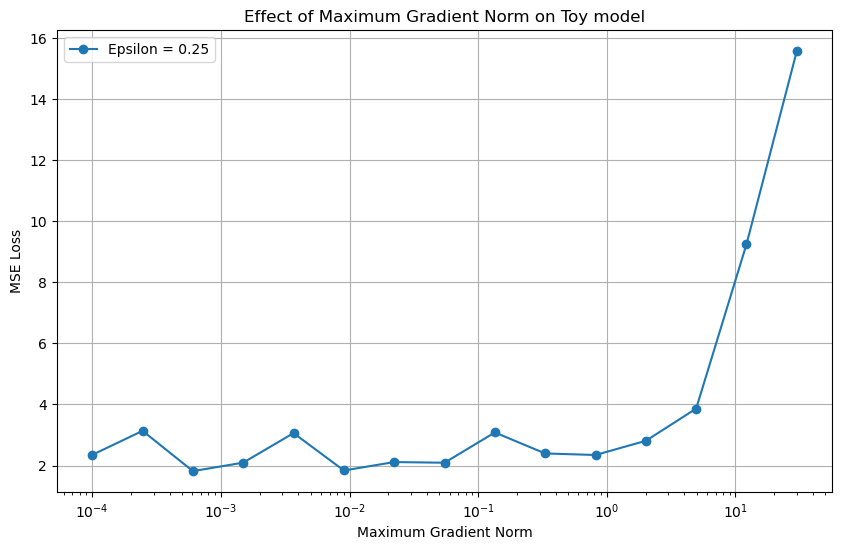

Running for epsilon: 1
Running with maximum gradient norm: 0.0001
 - Iterate epoch: 0
 - Iterate epoch: 1
 - Iterate epoch: 2
 - Iterate epoch: 3
 - Iterate epoch: 4
 - Iterate epoch: 5
 - Iterate epoch: 6
 - Iterate epoch: 7
 - Iterate epoch: 8
 - Iterate epoch: 9
Running with maximum gradient norm: 0.00024616309676992636
 - Iterate epoch: 0
 - Iterate epoch: 1
 - Iterate epoch: 2
 - Iterate epoch: 3
 - Iterate epoch: 4
 - Iterate epoch: 5
 - Iterate epoch: 6
 - Iterate epoch: 7
 - Iterate epoch: 8
 - Iterate epoch: 9
Running with maximum gradient norm: 0.0006059627021136012
 - Iterate epoch: 0
 - Iterate epoch: 1
 - Iterate epoch: 2
 - Iterate epoch: 3
 - Iterate epoch: 4
 - Iterate epoch: 5
 - Iterate epoch: 6
 - Iterate epoch: 7
 - Iterate epoch: 8
 - Iterate epoch: 9
Running with maximum gradient norm: 0.0014916565527935632
 - Iterate epoch: 0
 - Iterate epoch: 1
 - Iterate epoch: 2
 - Iterate epoch: 3
 - Iterate epoch: 4
 - Iterate epoch: 5
 - Iterate epoch: 6
 - Iterate epoch: 7

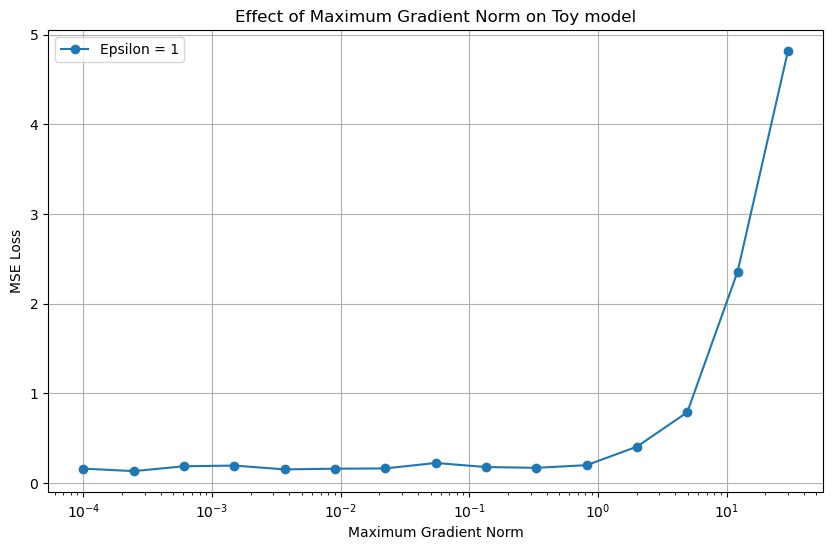

Running for epsilon: 4
Running with maximum gradient norm: 0.0001
 - Iterate epoch: 0
 - Iterate epoch: 1
 - Iterate epoch: 2
 - Iterate epoch: 3
 - Iterate epoch: 4
 - Iterate epoch: 5
 - Iterate epoch: 6
 - Iterate epoch: 7
 - Iterate epoch: 8
 - Iterate epoch: 9
Running with maximum gradient norm: 0.00024616309676992636
 - Iterate epoch: 0
 - Iterate epoch: 1
 - Iterate epoch: 2
 - Iterate epoch: 3
 - Iterate epoch: 4
 - Iterate epoch: 5
 - Iterate epoch: 6
 - Iterate epoch: 7
 - Iterate epoch: 8
 - Iterate epoch: 9
Running with maximum gradient norm: 0.0006059627021136012
 - Iterate epoch: 0
 - Iterate epoch: 1
 - Iterate epoch: 2
 - Iterate epoch: 3
 - Iterate epoch: 4
 - Iterate epoch: 5
 - Iterate epoch: 6
 - Iterate epoch: 7
 - Iterate epoch: 8
 - Iterate epoch: 9
Running with maximum gradient norm: 0.0014916565527935632
 - Iterate epoch: 0
 - Iterate epoch: 1
 - Iterate epoch: 2
 - Iterate epoch: 3
 - Iterate epoch: 4
 - Iterate epoch: 5
 - Iterate epoch: 6
 - Iterate epoch: 7

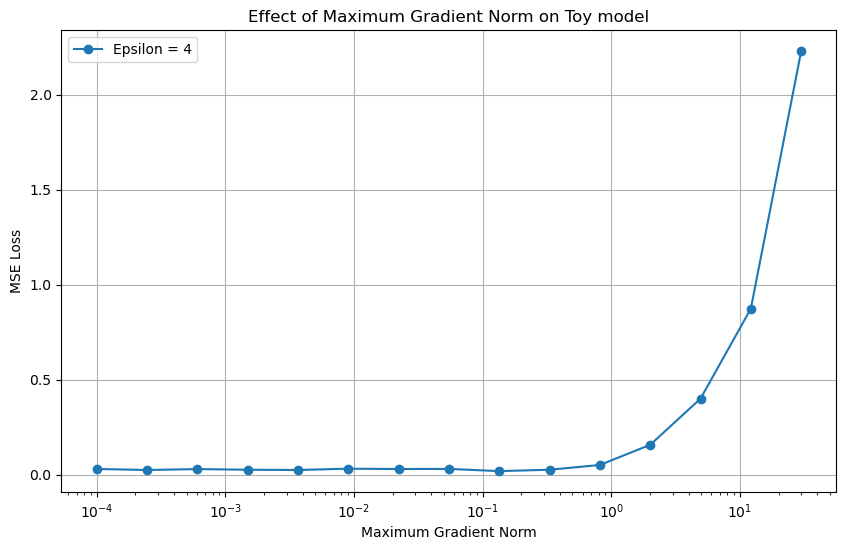

In [34]:
max_grad_norms = np.geomspace(1e-4, 30, 15)
epsilon_values = [0.25, 1, 4]

for epsilon in epsilon_values:
    print(f'Running for epsilon: {epsilon}')
    results = [train_dp_model(data_loader, epochs, learning_rate, max_grad_norm, epsilon) for max_grad_norm in max_grad_norms]
    plot_results(max_grad_norms, results, epsilon)
